In [5]:
import sys
!{sys.executable} -m pip install catboost

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-7.0.0-py3-none-any.whl.metadata (8.7 kB)
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 1.2 MB/s eta 0:01:22
   ---------------------------------------- 1.0/100.2 MB 1.7 MB/s eta 0:01:00
   ---------------------------------------- 1.0/100.2 MB 1.7 MB/s eta 0:01:00
    --------------------------------------- 1.3/100.2 MB 1.3 MB/s eta 0:01:16
   - -------------------------------------- 2.9/100.2 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 2.9/100.2 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 3.9/100


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
random_state = 42

In [8]:
df = pd.read_csv('data/balanced_dropout_dataset.csv')
print(df.shape)
print(df['Dropout'].value_counts())
df.head()

(4482, 18)
Dropout
1    2241
0    2241
Name: count, dtype: int64


,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Year of study,Department,Parental_Education,Dropout
0,19.2,0,25000.0,1,4.08,76.8,5,20.7,0,0,9.3,2.26,2.42,2.40,2,Engineering,Bachelor,1
1,21.3,1,36634.0,0,2.57,86.2,1,41.4,0,0,6.2,1.98,1.70,1.70,1,Engineering,High School,0
2,20.6,0,42980.0,1,2.94,78.9,4,45.8,0,0,6.2,1.65,1.53,1.56,4,Science,Bachelor,1
3,21.4,1,25000.0,1,4.94,75.5,1,51.4,1,1,5.3,2.18,2.20,2.20,1,Business,High School,1
4,21.5,1,97830.0,1,4.48,77.6,2,31.5,1,1,6.0,0.46,0.92,0.92,1,CS,High School,1


In [10]:
X = df.drop(columns=['Dropout'])
y = df['Dropout']

In [ ]:
cat_features = [
    'Gender',
    'Internet_Access',
    'Part_Time_Job',
    'Scholarship',
    'Department',
    'Parental_Education',
    'Year of study'
]


for col in cat_features:
    X[col] = X[col].astype(str)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state, stratify=y
)

print(X_train.shape, X_test.shape)

(3585, 17) (897, 17)


In [13]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='F1',
    random_state=random_state,
    verbose=100
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

0:	learn: 0.7448649	test: 0.7554585	best: 0.7554585 (0)	total: 330ms	remaining: 2m 44s
100:	learn: 0.7721448	test: 0.7485908	best: 0.7563396 (2)	total: 4.96s	remaining: 19.6s
200:	learn: 0.8012284	test: 0.7497194	best: 0.7563396 (2)	total: 8.94s	remaining: 13.3s
300:	learn: 0.8422512	test: 0.7511211	best: 0.7563396 (2)	total: 13.1s	remaining: 8.69s
400:	learn: 0.8673157	test: 0.7561521	best: 0.7575419 (336)	total: 17.3s	remaining: 4.28s
499:	learn: 0.8922390	test: 0.7603122	best: 0.7603122 (452)	total: 21.5s	remaining: 0us

bestTest = 0.7603121516
bestIteration = 452

Shrink model to first 453 iterations.


CatBoostClassifier(depth=6, eval_metric='F1', iterations=500, learning_rate=0.05, random_state=42, verbose=100)

In [14]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("="*50)

Accuracy:  0.7603
Precision: 0.7595
Recall:    0.7612
F1-Score:  0.7603
ROC-AUC:   0.8227


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76       449
           1       0.76      0.76      0.76       448

    accuracy                           0.76       897
   macro avg       0.76      0.76      0.76       897
weighted avg       0.76      0.76      0.76       897



[[341 108]
 [107 341]]


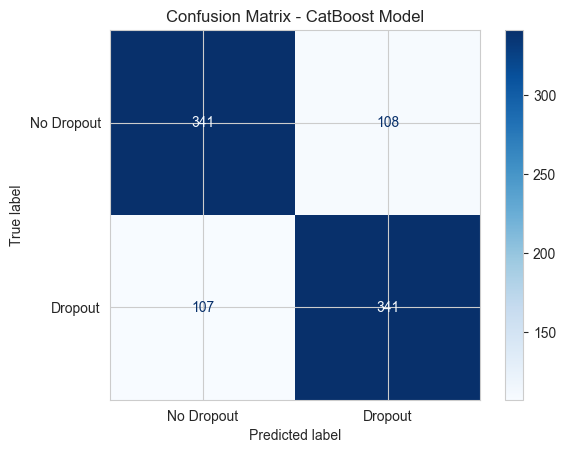

In [17]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Dropout', 'Dropout'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - CatBoost Model')
plt.show()